# Intro

* How to create a time-causal mask using vectors and matrices
* The "trick" to applying softmax to transform a time-causal mask into a probability distribution
* A key difference between GPT and BERT architectures

# Overview of "causal attention" algorithm

$$ A = \sigma\Big(\frac{QK^T}{\sqrt{d}}+M\Big) V$$

## Predicting the future based on the past

To predict the future, we can assign weight `1` to all past and present occurrences, and `0` to future occurrences.

Non-normalized:  
$$
\overbrace{1\;\;1\;\;1\;\;1\;\;1\;\;1\;\;1}^{Past}
\;\;\overbrace{1}^{Present}
\;\;\overbrace{0}^{Future}
$$

To avoid numerical instability, we normalize by dividing each active position by the number of active positions up to the current time step.

Uniform weighting:  
$$
\overbrace{\frac{1}{T}\;\;\frac{1}{T}\;\;\frac{1}{T}\;\;\frac{1}{T}\;\;\frac{1}{T}\;\;\frac{1}{T}\;\;\frac{1}{T}}^{Past}
\;\;\overbrace{\frac{1}{T}}^{Present}
\;\;\overbrace{0}^{Future}
$$

Some past information is more important than other past information. More recent context should usually receive higher weight.

Non-normalized attention scores:  
$$
\overbrace{2\;\;2\;\;4\;\;4\;\;4\;\;1\;\;1}^{Past}
\;\;\overbrace{1}^{Present}
\;\;\overbrace{0}^{Future}
$$

Softmax turns these scores into probabilities:

$$
\sigma\left(
\overbrace{2\;\;2\;\;4\;\;4\;\;4\;\;1\;\;1}^{Past}
\;\;\overbrace{1}^{Present}
\;\;\overbrace{0}^{Future}
\right)
$$

Example attention probabilities:

$$
\overbrace{0.04\;\;0.04\;\;0.27\;\;0.27\;\;0.27\;\;0.01\;\;0.01}^{Past}
\;\;\overbrace{0.01}^{Present}
\;\;\overbrace{0.005}^{Future}
$$

The problem is that the future has non-zero information value. That's why we change 0 in Future to $-\infty$ because $\lim_{e\rightarrow -\infty} e^x = 0$

So, final shape is Softmax with negative infinity in future:

Softmax turns these scores into probabilities:

$$
\sigma\left(
\overbrace{2\;\;2\;\;4\;\;4\;\;4\;\;1\;\;1}^{Past}
\;\;\overbrace{1}^{Present}
\;\;\overbrace{-\infty}^{Future}
\right)
$$

Which returns:

$$
\overbrace{0.04\;\;0.04\;\;0.27\;\;0.27\;\;0.27\;\;0.01\;\;0.01}^{Past}
\;\;\overbrace{0.01}^{Present}
\;\;\overbrace{0}^{Future}
$$

# Computing Algebraically

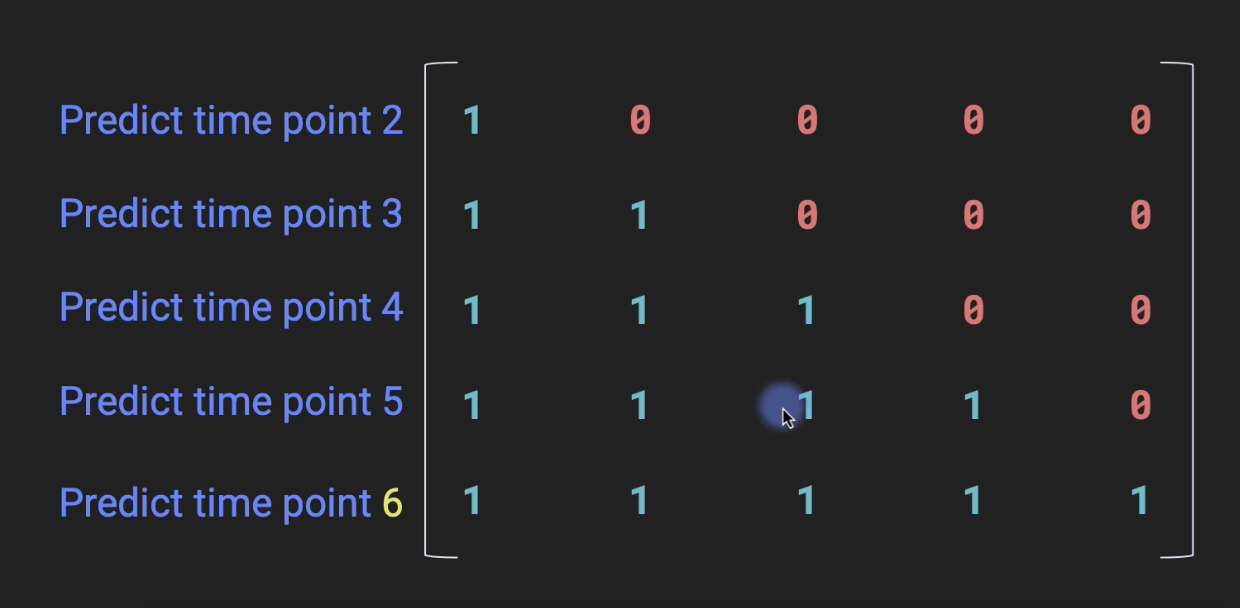

We need to remember about infinity and softmax:

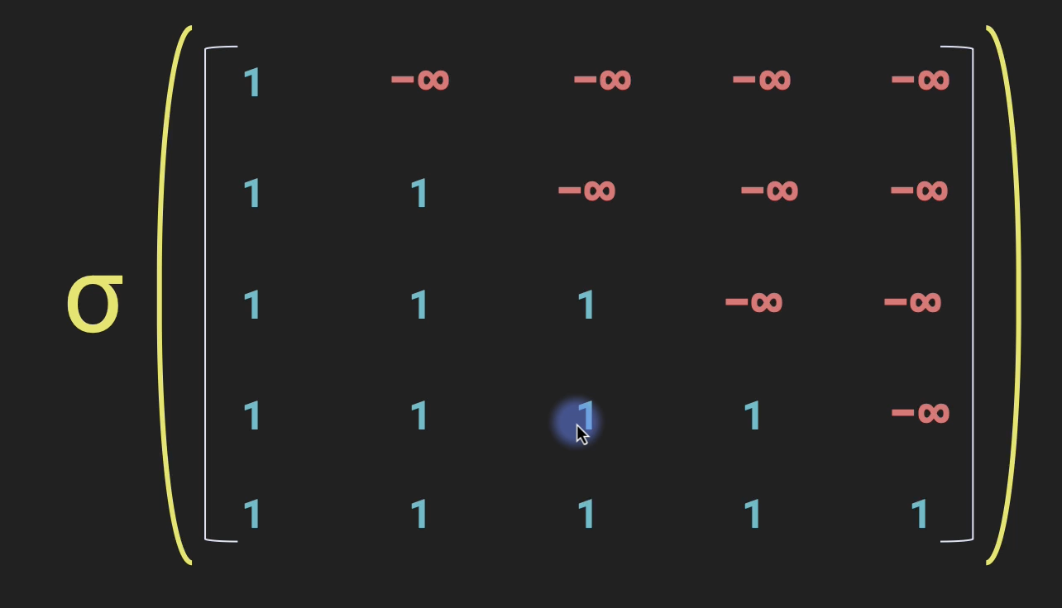

# Averaging the past while ignorign the future

* How to create a time-causal mask (vector and matrix) in PyTorch
* Several ways to implement the causal mask matrix

## Goals

1. Creating a time-causal vector
2. Show that the past's impact depends on the weights
3. Create time-causal matrices
4. Use random activation matrices instead of 1's
5. Test three implementations for computation time

## Imports

In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as F

import numpy as np

## Equal-weighted average of the past

In [4]:
the_past = torch.tensor([4,1,-2,-3])
N = len(the_past)

weights = torch.ones(N) / N

print(f'The past: {the_past}')
print(f'Weights (importance) of the past: {weights}')
print(f'Sum over all weights: {sum(weights)}')

The past: tensor([ 4,  1, -2, -3])
Weights (importance) of the past: tensor([0.2500, 0.2500, 0.2500, 0.2500])
Sum over all weights: 1.0


In [5]:
the_present = sum(the_past * weights)
print(f'The present (weighted sum of the past): {the_present}')

The present (weighted sum of the past): 0.0


Weighted average of the past

In [6]:
weights = torch.tensor([2,1,1,1])
print(f'Sum of weights: {sum(weights)}.')

Sum of weights: 5.


In [9]:
linear_weights  = weights / sum(weights)
softmax_weights = torch.exp(weights) / sum(torch.exp(weights))

print(f'Scaled weights: {linear_weights}')
print(f'\tTheir sum: {sum(linear_weights)}')

print(f'\nSoftmax weights: {softmax_weights}')
print(f'\tTheir sum: {sum(softmax_weights)}')

Scaled weights: tensor([0.4000, 0.2000, 0.2000, 0.2000])
	Their sum: 1.0

Softmax weights: tensor([0.4754, 0.1749, 0.1749, 0.1749])
	Their sum: 1.0


In [11]:
the_present_linear  = sum(the_past * linear_weights)
the_present_softmax = sum(the_past * softmax_weights)

print(f'The present (linear sum of the past):  {the_present_linear}')
print(f'The present (sofmtax sum of the past): {the_present_softmax}')

The present (linear sum of the past):  0.8000000715255737
The present (sofmtax sum of the past): 1.2019567489624023


It's worthy to note that we don't do here:

$$ \sum softmax(x) > \sum x $$

but

$$ \sum (softmax(x)\times past) > \sum x \times past$$

Softmax causes that weights are moved more to higher values, therefore it's natural that the sum of products will be higher that sum of products before pushing weights toward highest value.

# Ignoring the future

In [14]:
the_data = torch.tensor([4,1,-2,-3,8,3,-1])
present_moment = 4
N = len(the_data)

print(f'Past data:   {the_data[:present_moment]}')
print(f'The present: {the_data[present_moment]}')
print(f'The future:  {the_data[present_moment+1:]}')

Past data:   tensor([ 4,  1, -2, -3])
The present: 8
The future:  tensor([ 3, -1])


In [15]:
past_weights = torch.ones(N)
past_weights[present_moment+1:] = 0
past_weights

tensor([1., 1., 1., 1., 1., 0., 0.])

In [17]:
past_weights_linear = past_weights / torch.sum(past_weights)

print(f'Scaled weights: {past_weights_linear}')
print(f'\tTheir sum: {sum(past_weights_linear)}')

Scaled weights: tensor([0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000])
	Their sum: 1.0


In [19]:
past_weights_softmax = torch.exp(past_weights) / torch.sum(torch.exp(past_weights))

print(f'Softmax weights: {past_weights_softmax}')
print(f'\tTheir sum: {sum(past_weights_softmax)}')

Softmax weights: tensor([0.1743, 0.1743, 0.1743, 0.1743, 0.1743, 0.0641, 0.0641])
	Their sum: 1.0


In [20]:
# recreate the weights for the past, but setting future values to -infinity
past_weights = torch.ones(N)
past_weights[present_moment+1:] = -torch.inf

# softmaxify
past_weights_softmax = torch.exp(past_weights) / torch.sum(torch.exp(past_weights))

# print the results
print(f'Unscaled weights:  {past_weights}')
print(f'Scaled weights:    {past_weights_softmax}')
print(f'\tTheir sum: {sum(past_weights_softmax)}')

Unscaled weights:  tensor([1., 1., 1., 1., 1., -inf, -inf])
Scaled weights:    tensor([0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000])
	Their sum: 1.0


In [21]:
# rows are calculation steps, columns are time points
tril = torch.tril(torch.ones(9,9))
tril

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [22]:
tril[tril==0] = -torch.inf
tril

tensor([[1., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [1., 1., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [1., 1., 1., -inf, -inf, -inf, -inf, -inf, -inf],
        [1., 1., 1., 1., -inf, -inf, -inf, -inf, -inf],
        [1., 1., 1., 1., 1., -inf, -inf, -inf, -inf],
        [1., 1., 1., 1., 1., 1., -inf, -inf, -inf],
        [1., 1., 1., 1., 1., 1., 1., -inf, -inf],
        [1., 1., 1., 1., 1., 1., 1., 1., -inf],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [27]:
# softmaxify
tril_softmax = F.softmax(tril, dim=-1)
tril_softmax[:,0]

tensor([1.0000, 0.5000, 0.3333, 0.2500, 0.2000, 0.1667, 0.1429, 0.1250, 0.1111])

In [35]:
for time_point in range(tril.shape[0]):
  print(f'\nWeights for calculation at time point {time_point}:')
  print(f'\t{tril_softmax[time_point]}')


Weights for calculation at time point 0:
	tensor([1., 0., 0., 0., 0., 0., 0., 0., 0.])

Weights for calculation at time point 1:
	tensor([0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])

Weights for calculation at time point 2:
	tensor([0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])

Weights for calculation at time point 3:
	tensor([0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000])

Weights for calculation at time point 4:
	tensor([0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000, 0.0000])

Weights for calculation at time point 5:
	tensor([0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000, 0.0000])

Weights for calculation at time point 6:
	tensor([0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000, 0.0000])

Weights for calculation at time point 7:
	tensor([0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.0000])

Weights for calculation at time point 8:
	t

Final demo with random activations

In [43]:
activations = torch.randn(N,N)
tril = torch.tril(torch.ones(N,N))

print('-- ORIGINAL ACTIVATIONS:')
print(activations)

print('\n-- PAST WEIGHTING FACTOR:')
print(tril)

scaled_activations = activations * tril
scaled_activations[scaled_activations == 0] = -torch.inf
print('\n-- SCALED PAST ACTIVATIONS:')
print(scaled_activations)

softmax_past = F.softmax(scaled_activations, dim = -1)
print('\n-- SOFTMAX PAST ACTIVATIONS:')
print(softmax_past)

-- ORIGINAL ACTIVATIONS:
tensor([[ 0.3591, -0.2640,  0.5101, -0.0988,  0.9733,  0.7650, -0.1648],
        [-0.2324,  1.3311,  0.8568, -0.2056, -0.2374, -2.0540, -0.1374],
        [-0.7829,  1.5355, -0.7105,  0.0096, -0.3384,  0.2379,  1.6752],
        [ 2.4754,  0.0216,  0.5760, -0.4383,  2.2065,  1.4857, -0.0308],
        [ 0.4998, -0.0466, -0.8916,  0.6074,  0.8808,  0.0859,  0.7577],
        [-0.2194,  0.9271,  0.9113,  0.7234, -0.3745,  0.8948,  1.9780],
        [-0.4216,  1.1381,  0.0950, -0.2838, -0.2530, -0.4921,  0.7603]])

-- PAST WEIGHTING FACTOR:
tensor([[1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1.]])

-- SCALED PAST ACTIVATIONS:
tensor([[ 0.3591,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.2324,  1.3311,    -inf,    -inf,    -inf,    -inf,    -

In [45]:
# confirm:
torch.sum(softmax_past, dim = -1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

# Sum up

* Matrix multiplication with masks are an efficient way to avoid for-loops
* PyTorch has optimized functions that fuse the attention algorithm, including the causal mask (next lecture).

---

> *Notebook is based on Mike X Cohen course. Notebook was modified.*




